In [3]:
import numpy as np
import pandas as pd
from numpy.typing import NDArray
import matplotlib.pyplot as plt
random = np.random.default_rng(seed=12)    # remove seed for random trials

In [17]:
def trapezoid_shaper(v: NDArray, tau: float, T: float, k: int, l: int):
    """Shapes input signal pulse into a trapezoid for pulse height measurement.
    Algorithm by Jordanov et al. (1994)

    Args:
        v (np.ndarray): input signal
        tau (float): exponential decay constant
        T (float): sampling period
        k (int): delay parameter (rise)
        l (int): delay parameter (decay)

    Returns:
        np.ndarray: shaped signal
    """
    n_samples = len(v)
    M = 1 / (np.exp(T / tau) - 1)
    max_delay = k + l
    v_padded = np.concatenate(([0] * max_delay, v))

    dkl = np.zeros_like(v_padded)
    p = np.zeros_like(v_padded)
    r = np.zeros_like(v_padded)
    s = np.zeros_like(v_padded)

    for n in range(max_delay, n_samples + max_delay):
        dkl[n] = v_padded[n] - v_padded[n - k] - v_padded[n - l] + v_padded[n - k - l]
        p[n] = p[n - 1] + dkl[n]
        r[n] = p[n] + M*dkl[n]
        s[n] = s[n - 1] + r[n]

    return s[max_delay:]

def rccr2_filter(x: NDArray):
    """
    Apply the three-stage recursive RC-CR2 filter to the input signal x.

    Args:
        x (numpy.ndarray): Input signal.

    Returns:
        y3 (numpy.ndarray): Output signal after three stages of filtering.
    """
    x = np.asarray(x)
    N = len(x)

    # Initialize output arrays
    y1 = np.zeros(N+1)
    y2 = np.zeros(N+1)
    y3 = np.zeros(N+1)

    for n in range(1, N):
        y1[n] = 0.15 * x[n] + 0.84 * y1[n-1]
        y2[n] = 0.91 * y1[n] - 0.91 * y1[n-1] + 0.84 * y2[n-1]
        y3[n] = 0.91 * y2[n] - 0.91 * y2[n-1] + 0.84 * y3[n-1]

    return y3

def add_exp_pulse(s, pos, a, tau):
    """Add an exponentially decaying pulse to a base signal.

    Args:
        s (numpy.ndarray): base signal
        pos (int): starting index of the pulse
        a (float): height of the added pulse
        tau (float): exponential decay constant
        samples (int): number of samples in the 

    Returns:
        numpy.ndarray: base signal with exponential pulse starting from pos
    """
    samples = len(s)
    x = np.linspace(0, 1, samples)
    x = np.roll(x, pos)
    s1 = a * np.exp(- x / tau)
    s1[:pos] = 0
    return s + s1

def triggers(signal, threshold):
    """Given a threshold amplitude, find the triggers based on the RC-CR2 filtered signal.

    Args:
        signal (numpy.ndarray): RC-CR2 filtered signal
        threshold (float): threshold amplitude for arming the trigger
        min_dead_time (int): the minimum amount of samples the dead time lasts (to avoid retriggering on overshoot)
    Returns:
        list: trigger indices
    """
    trigger_indices = []
    i = 0
    while i < len(signal):
        over_threshold = np.nonzero((signal[i:] > threshold).astype(np.int64))[0]
        # check if there are any more samples above the threshold and 
        if over_threshold.shape[0] > 0:
            threshold_index = over_threshold[0] + i
        else:
            break
        try:
            trigger_index = np.nonzero((signal[threshold_index:] < 0))[0][0]
            i = trigger_index + threshold_index
            trigger_indices.append(i)
        except IndexError:
            break

    return trigger_indices

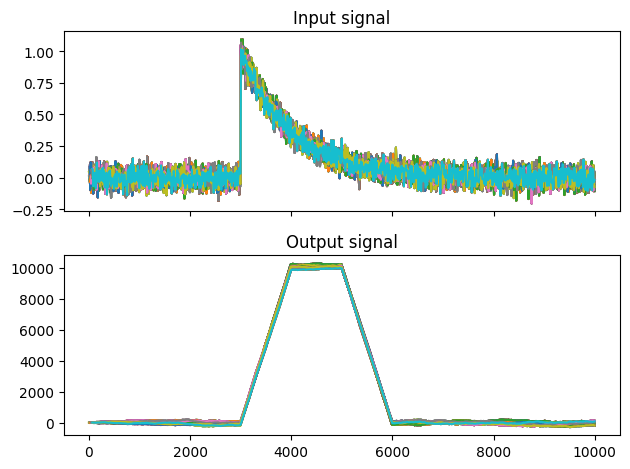

In [36]:
# Jittering MC
repeats = 1000
samples = 10000     # length of signal buffer
T = 0.001           # sample period (tune)
tau = 0.1           # time constant (tune)
k = 100             # filter rise delay (tune)
l = 200             # filter decay delay (tune)
sigma = 0.05        # Gaussian noise standard deviation
a = 1               # amplitude of pulse

# White noise as base
x = random.normal(0, sigma, size=samples)

# Add an exponentially decaying pulse to the noisy base
signal = add_exp_pulse(x, pos=3000, a=1, tau=tau)
maxima = []

# Plotting just as a sanity check
fig, axs = plt.subplots(nrows=2, sharex=True)

for i in range(repeats):
    # Generate a subsample with one tenth of original sampling frequency with a randomly shifted
    # starting point.
    subsample_index = np.arange(start=random.integers(100), stop=10000, step=10)
    subsample = signal[subsample_index]
    s = trapezoid_shaper(subsample, tau, T, k, l)
    if i < 100: # plot the first 100 curves
        axs[0].plot(subsample_index, subsample)
        axs[0].set_title("Input signal")
        axs[1].plot(subsample_index, s)
        axs[1].set_title("Output signal")
    
    # Log the maximum for the histogram plotted in the cell below
    maxima.append(np.nanmax(s))

plt.tight_layout()

Text(0, 0.5, 'N')

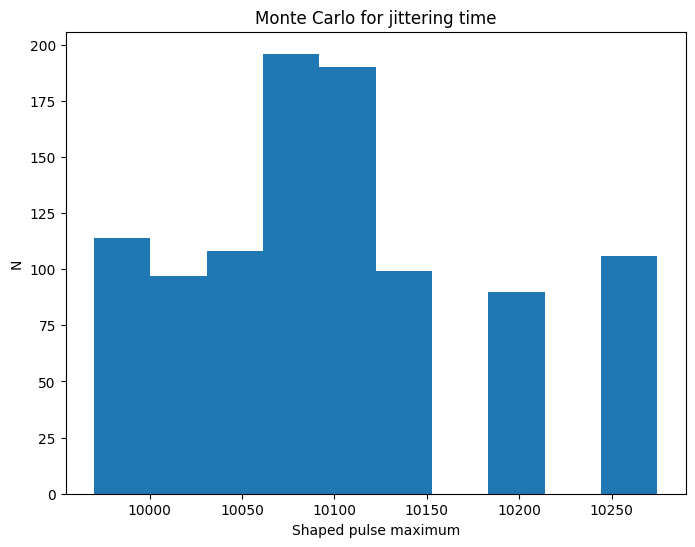

In [37]:
fig, axs = plt.subplots(figsize=(8,6))
plt.title("Monte Carlo for jittering time")
plt.hist(maxima)
plt.xlabel("Shaped pulse maximum")
plt.ylabel("N")

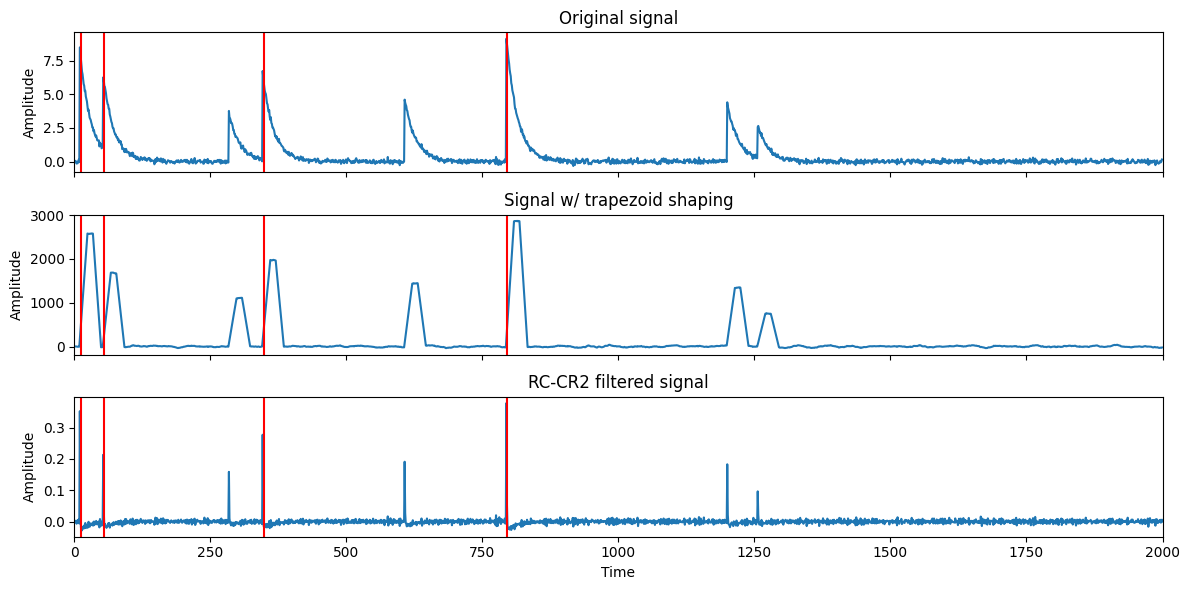

In [38]:
# Random pulse train

samples = 2000     # length of signal buffer
T = 0.0005           # sample period (tune)
tau = 0.01           # time constant (tune)
k = 15          # filter rise delay (tune)
l = 25             # filter decay delay (tune)
sigma = 0.1        # Gaussian noise standard deviation
a = 1               # amplitude of pulse

signal = random.normal(0, sigma, size=samples)
rate = 1 / (20 * tau / T)
t = 0
pulse_positions = []
while t < samples:
    dt = random.exponential(scale=1/rate)
    t += int(dt)
    if t < samples:
        pulse_positions.append(t)
for pos in pulse_positions:
    signal = add_exp_pulse(signal, pos=pos, a=random.uniform(1, 10), tau=tau)

trigger_sig = rccr2_filter(signal)
trapez_sig = trapezoid_shaper(signal, tau, T, k, l)

threshold = 0.2
trigs = triggers(trigger_sig, threshold)

fig, axs = plt.subplots(nrows=3, sharex=True, figsize=(12, 6))
axs[0].set_title("Original signal")
axs[0].set_ylabel("Amplitude")
axs[0].plot(signal)

axs[1].set_title("Signal w/ trapezoid shaping")
axs[1].set_ylabel("Amplitude")
axs[1].plot(trapez_sig)

axs[2].set_title("RC-CR2 filtered signal")
axs[2].set_ylabel("Amplitude")
axs[2].set_xlabel("Time")
axs[2].plot(trigger_sig)

for ax in axs:
    for trig in trigs:
        ax.axvline(trig, color="red")

axs[2].set_xlim(0, 2000)
plt.tight_layout()

### Real data

- concatenated measured pulses with random interval sampled from exponential distribution

In [5]:
from scipy.signal import decimate
df = pd.read_csv("data/DataR_D4@N6781_16256_MPPC_Hamamatsu_Plastic_no_source_1_1.csv", header=None, sep=";")

# Tweak these to get flat top
rate = 200
tau = 0.01
T = 0.005
k = 5
l = 8
sigma = 10

signal_between_const = 1e4  # just a scaling constant for time
csv_length = 20
t = 0
signal = np.array([df.iloc[0, 5]])

for i in range(csv_length):
    pulse = decimate(df.iloc[i, 5:].values.astype(int), q=10)   # antialiasing + downsampling
    pulse = decimate(pulse, q=10)
    # Generate a random time between pulses from exponential distribution
    dt = signal_between_const * random.exponential(scale = 1/rate)

    # Linearly interpolate dt amount of samples between two pulses, noise added on top
    signal_between = np.interp(np.arange(dt), [0, dt], [signal[-1], pulse[0]]) + random.normal(0, sigma, int(np.ceil(dt)))
    signal = np.append(signal, signal_between)
    signal = np.append(signal, pulse)


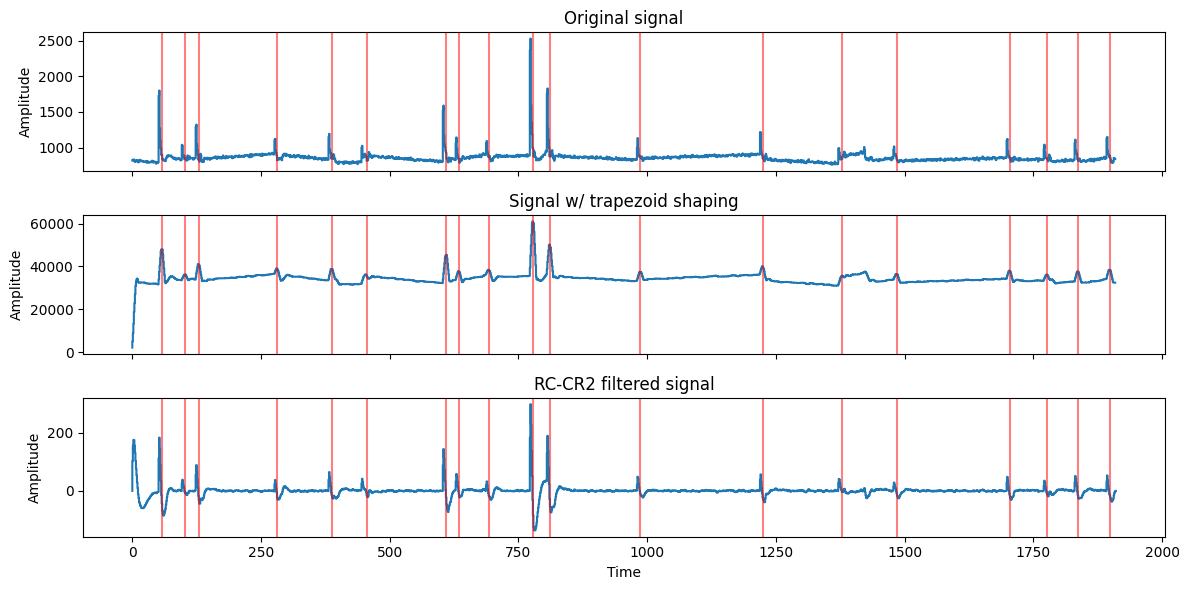

20


In [23]:
trigger_sig = rccr2_filter(signal)
trapez_sig = trapezoid_shaper(signal, tau, T, k, l)

threshold = 20  # tweak this to accept pulses just above the noise floor
trigs = triggers(trigger_sig, threshold)

# Plots
fig, axs = plt.subplots(nrows=3, figsize=(12, 6), sharex=True)
axs[0].set_title("Original signal")
axs[0].set_ylabel("Amplitude")
axs[0].step(np.arange(len(signal)), signal)

axs[1].set_title("Signal w/ trapezoid shaping")
axs[1].set_ylabel("Amplitude")
axs[1].step(np.arange(len(trapez_sig)), trapez_sig)

axs[2].set_title("RC-CR2 filtered signal")
axs[2].set_ylabel("Amplitude")
axs[2].set_xlabel("Time")
axs[2].step(np.arange(len(trigger_sig)), trigger_sig)

# Plot the triggers on each Axes
for ax in axs:
    for trig in trigs[1:]:
        ax.axvline(trig, color="red", alpha=0.5)

# Set limit of x to view a single pulse better
# axs[2].set_xlim(700, 850)
# axs[0].set_ylim(0, 2500)
plt.tight_layout()
plt.show()
print(len(trigs))

(array([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  3.,  0.,
         0., 10.,  1.,  0.,  0.,  1.]),
 array([ 0.        ,  1.10526316,  2.21052632,  3.31578947,  4.42105263,
         5.52631579,  6.63157895,  7.73684211,  8.84210526,  9.94736842,
        11.05263158, 12.15789474, 13.26315789, 14.36842105, 15.47368421,
        16.57894737, 17.68421053, 18.78947368, 19.89473684, 21.        ]),
 <BarContainer object of 19 artists>)

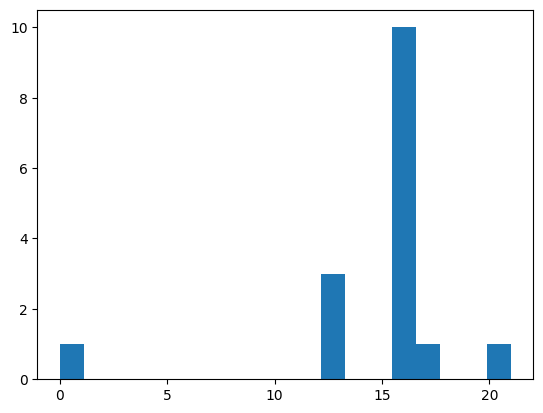

In [8]:
plateau_starts = []
for trig in trigs[1:]:
    try:
        plateau_starts.append((np.argwhere(np.diff(trapez_sig[trig-k-l:trig+k+l], n=2) < -500)[0])[0])
    except IndexError:
        continue

plateau_starts = np.array(plateau_starts)
plt.hist(plateau_starts, bins=np.linspace(min(plateau_starts), max(plateau_starts), 20))

In [9]:
import warnings
from itertools import product

def triggers_4brute(signal, threshold, max_triggers=25):
    trigger_indices = []
    i = 0
    j = -1  # trigger counter
    while i < len(signal):
        over_threshold = np.nonzero((signal[i:] > threshold).astype(np.int64))[0]
        # check if there are any more samples above the threshold and 
        if over_threshold.shape[0] > 0:
            threshold_index = over_threshold[0] + i
        else:
            break
        try:
            trigger_index = np.nonzero((signal[threshold_index:] < 0))[0][0]
            i = trigger_index + threshold_index
            trigger_indices.append(i)
            j += 1
            if j == max_triggers:
                warnings.warn("Amount of triggers larger than expected with given threshold, ignoring", category=RuntimeWarning)
                break
        except IndexError:
            break

    return trigger_indices

from scipy.signal import resample
df = pd.read_csv("data/DataR_D4@N6781_16256_MPPC_Hamamatsu_Plastic_no_source_1_1.csv", header=None, sep=";")

# Tweak these to get flat top
rate = 200


signal = np.array([df.iloc[0, 5]])

# Brute force RC-CR2 parameters
p1_range = np.linspace(0.1, 1.0, 10)
p2_range = np.linspace(0.1, 1.0, 10)
p3_range = np.linspace(0.1, 1.0, 10)
threshold_range = np.linspace(0.1, 100, 1000)
for p1, p2, p3, threshold in product(p1_range, p2_range, p3_range, threshold_range):
    for i in range(100):
        pulse = resample(df.iloc[i, 5:].values.astype(int), len(df.iloc[i, 5:].to_numpy().ravel()) // 100)  # resample to 1 MHz

        # Generate a random time between pulses from exponential distribution
        dt = signal_between_const * random.exponential(scale = 1/rate)

        # Linearly interpolate dt amount of samples between two pulses, noise added on top
        signal_between = np.interp(np.arange(dt), [0, dt], [signal[-1], pulse[0]]) + random.normal(0, sigma, int(np.ceil(dt)))
        signal = np.append(signal, signal_between)
        signal = np.append(signal, pulse)

        trigger_sig = rccr2_filter(signal, p1, p2, p3)
        trigs = triggers_4brute(trigger_sig, threshold, max_triggers=i)
        if len(trigs) > i:
            break
        
    print("All triggers found with params", p1, p2, p3, threshold)


TypeError: rccr2_filter() takes 1 positional argument but 4 were given

In [ ]:
threshold_range = np.linspace(0.1, 100, 100)

In [ ]:
threshold_range

array([  0.1       ,   1.10909091,   2.11818182,   3.12727273,
         4.13636364,   5.14545455,   6.15454545,   7.16363636,
         8.17272727,   9.18181818,  10.19090909,  11.2       ,
        12.20909091,  13.21818182,  14.22727273,  15.23636364,
        16.24545455,  17.25454545,  18.26363636,  19.27272727,
        20.28181818,  21.29090909,  22.3       ,  23.30909091,
        24.31818182,  25.32727273,  26.33636364,  27.34545455,
        28.35454545,  29.36363636,  30.37272727,  31.38181818,
        32.39090909,  33.4       ,  34.40909091,  35.41818182,
        36.42727273,  37.43636364,  38.44545455,  39.45454545,
        40.46363636,  41.47272727,  42.48181818,  43.49090909,
        44.5       ,  45.50909091,  46.51818182,  47.52727273,
        48.53636364,  49.54545455,  50.55454545,  51.56363636,
        52.57272727,  53.58181818,  54.59090909,  55.6       ,
        56.60909091,  57.61818182,  58.62727273,  59.63636364,
        60.64545455,  61.65454545,  62.66363636,  63.67